# Model Explainability — Home Credit Default Risk

This notebook answers the question: **why did the model score an applicant the way it did?**

Explainability in credit scoring is not optional — it is a regulatory requirement.  
Under ECOA (Equal Credit Opportunity Act) and GDPR Article 22, lenders must be able to:
- Provide **specific reasons** for adverse credit decisions
- Demonstrate the model does not encode **prohibited characteristics** (race, gender, religion)
- Give regulators an **auditable account** of how decisions are made

We use **SHAP (SHapley Additive exPlanations)** — a game-theory-based method that attributes each prediction to individual feature contributions in a mathematically consistent way.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
shap.initjs()

DATA_PATH    = '../data/processed/train_engineered.csv'
RANDOM_STATE = 42
SAMPLE_N     = 5000
import pickle


---
## Setup: Load Data & Calibrated Model

We load `train_engineered.csv` and reproduce the same 80/20 split so `X_test` / `y_test` are identical to those used in the modelling and risk-policy notebooks.  
The calibrated model is loaded from `models/xgboost_calibrated.pkl`.

> **SHAP note:** `TreeExplainer` works on the underlying XGBoost tree model (`xgb_cal.base_model`). Isotonic calibration is a monotone post-processing step that preserves feature ranking, so SHAP values computed on the base model correctly explain each feature's contribution to the final risk ordering. Predicted *probabilities* shown alongside are taken from `xgb_cal` (calibrated).

In [2]:
df = pd.read_csv(DATA_PATH)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Define wrapper class so pickle can deserialise it
class IsotonicCalibratedModel:
    def __init__(self, base_model, iso_reg):
        self.base_model = base_model
        self.iso_reg    = iso_reg
    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.iso_reg.predict(raw)
        return np.column_stack([1 - cal, cal])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

with open('../models/xgboost_calibrated.pkl', 'rb') as f:
    xgb_cal = pickle.load(f)

# Base XGBoost model — used by TreeExplainer
xgb_base = xgb_cal.base_model

# Calibrated probabilities for the test set
y_prob_cal = xgb_cal.predict_proba(X_test)[:, 1]
y_prob_raw = xgb_base.predict_proba(X_test)[:, 1]

def assign_band(p, t_low=None, t_high=None):
    if t_low is None:
        t_low  = float(np.percentile(y_prob_cal, 60))
        t_high = float(np.percentile(y_prob_cal, 85))
    if p < t_low:
        return 'LOW'
    elif p <= t_high:
        return 'MEDIUM'
    return 'HIGH'

bands = pd.Series(y_prob_cal, index=X_test.index).map(assign_band)

print(f'Model loaded — {type(xgb_cal).__name__}')
print(f'Test set: {len(X_test):,} rows')
print(f'Band distribution (calibrated scores):')
print(bands.value_counts().to_string())


Model loaded — IsotonicCalibratedModel
Test set: 61,503 rows
Band distribution (calibrated scores):
LOW       31509
MEDIUM    21113
HIGH       8881


---
## 1. Global Explainability — SHAP

### What is SHAP?

SHAP assigns each feature a **contribution value** for a specific prediction. The contribution is defined using Shapley values from cooperative game theory:

> *The SHAP value for feature X is the average marginal contribution of X across all possible orderings of features.*

Key properties:
- **Local accuracy**: SHAP values sum to the difference between the prediction and the model baseline
- **Consistency**: if a feature contributes more to the model output, its SHAP value never decreases
- **Missingness**: features with no effect get SHAP value = 0

For XGBoost we use `TreeExplainer` — an exact, fast algorithm that exploits the tree structure (no sampling needed, O(TLD²) complexity).

We sample 5,000 test rows for the global plots to keep computation fast.

In [3]:
# Sample for global analysis
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test), size=SAMPLE_N, replace=False)
X_sample   = X_test.iloc[sample_idx]

# TreeExplainer runs on the base XGBoost model (isotonic calibration is
# a monotone post-step that preserves SHAP feature rankings)
explainer   = shap.TreeExplainer(xgb_base)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values computed — shape: {shap_values.shape}')
print(f'Base value (log-odds): {explainer.expected_value:.4f}')
# Show calibrated base rate for reference
print(f'Calibrated base rate : {y_prob_cal.mean():.4f}')


SHAP values computed — shape: (5000, 101)
Base value (log-odds): -0.0006
Calibrated base rate : 0.0807


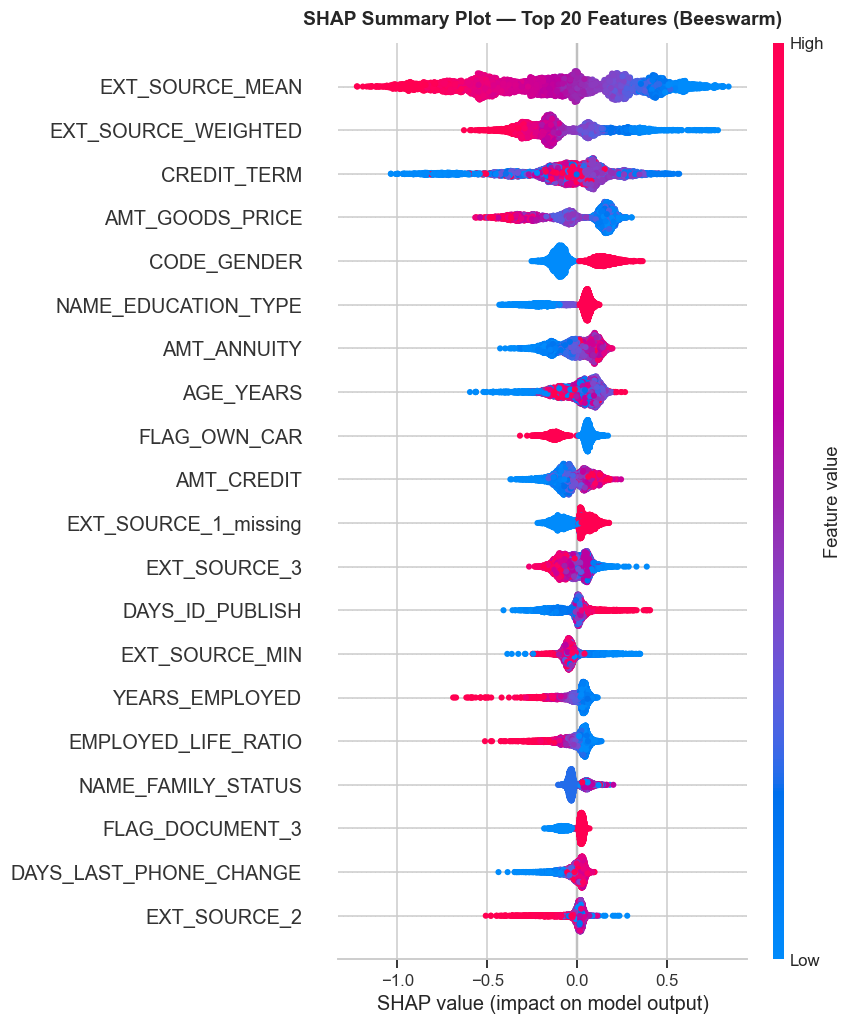

In [4]:
# Beeswarm summary — top 20 features
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False,
)
plt.title('SHAP Summary Plot — Top 20 Features (Beeswarm)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


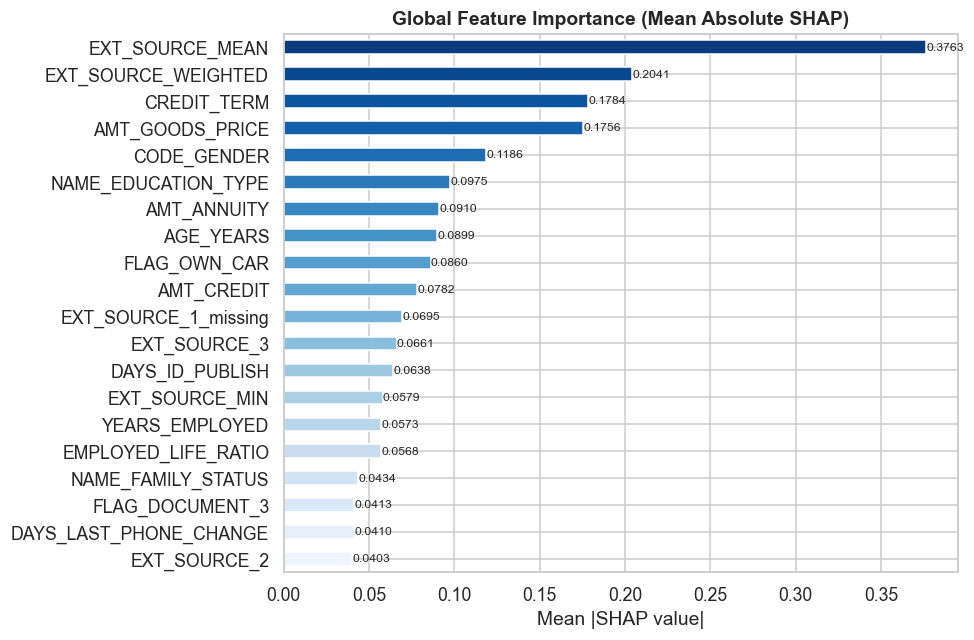

Top 10 features by mean |SHAP|:
EXT_SOURCE_MEAN        0.3763
EXT_SOURCE_WEIGHTED    0.2041
CREDIT_TERM            0.1784
AMT_GOODS_PRICE        0.1756
CODE_GENDER            0.1186
NAME_EDUCATION_TYPE    0.0975
AMT_ANNUITY            0.0910
AGE_YEARS              0.0899
FLAG_OWN_CAR           0.0860
AMT_CREDIT             0.0782


In [5]:
# Bar plot — mean |SHAP| per feature
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

top20 = mean_abs_shap.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('Blues_r', len(top20))
top20[::-1].plot.barh(ax=ax, color=colors[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance (Mean Absolute SHAP)', fontweight='bold')
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=8
    )
plt.tight_layout()
plt.show()

print('Top 10 features by mean |SHAP|:')
print(top20.head(10).round(4).to_string())


---
## 2. Local Explainability — Per Applicant

Global SHAP tells us which features matter *on average*. Local SHAP tells us why **this specific applicant** received their score.

We select one representative applicant from each risk band and show:
- Their predicted default probability and risk band
- The top features pushing their score **up** (toward default)
- The top features pushing their score **down** (away from default)
- A waterfall plot showing the full SHAP decomposition

The waterfall plot reads: start from the base rate → apply each feature's contribution → arrive at this applicant's final score.

In [6]:
band_examples = {}
for band in ['LOW', 'MEDIUM', 'HIGH']:
    idx = bands[bands == band].index[0]
    band_examples[band] = idx

X_local    = X_test.loc[list(band_examples.values())]
shap_local = explainer.shap_values(X_local)

for i, (band, idx) in enumerate(band_examples.items()):
    prob_cal = xgb_cal.predict_proba(X_test.loc[[idx]])[:, 1][0]
    prob_raw = xgb_base.predict_proba(X_test.loc[[idx]])[:, 1][0]
    sv       = shap_local[i]
    feat_shap = pd.Series(sv, index=feature_names).sort_values()

    print(f'\n{"="*58}')
    print(f'Band: {band}  |  Calibrated prob: {prob_cal:.4f}  |  Raw prob: {prob_raw:.4f}')
    print(f'Top 5 factors INCREASING default risk:')
    for feat, val in feat_shap.nlargest(5).items():
        raw_val = float(X_test.loc[idx, feat])
        print(f'  + {feat:<35}  SHAP={val:+.4f}  value={raw_val:.4f}')
    print(f'Top 5 factors DECREASING default risk:')
    for feat, val in feat_shap.nsmallest(5).items():
        raw_val = float(X_test.loc[idx, feat])
        print(f'  - {feat:<35}  SHAP={val:+.4f}  value={raw_val:.4f}')



Band: LOW  |  Calibrated prob: 0.0441  |  Raw prob: 0.3333
Top 5 factors INCREASING default risk:
  + CODE_GENDER                          SHAP=+0.1316  value=1.0000
  + EMPLOYED_LIFE_RATIO                  SHAP=+0.1261  value=0.0078
  + AGE_YEARS                            SHAP=+0.1235  value=36.9800
  + AMT_ANNUITY                          SHAP=+0.0829  value=30676.5000
  + EXT_SOURCE_1_missing                 SHAP=+0.0734  value=1.0000
Top 5 factors DECREASING default risk:
  - AMT_GOODS_PRICE                      SHAP=-0.3194  value=688500.0000
  - NAME_EDUCATION_TYPE                  SHAP=-0.1798  value=1.0000
  - AMT_REQ_CREDIT_BUREAU_QRT            SHAP=-0.1768  value=1.0000
  - CREDIT_TERM                          SHAP=-0.1574  value=25.1102
  - FLAG_OWN_CAR                         SHAP=-0.1294  value=1.0000

Band: MEDIUM  |  Calibrated prob: 0.0649  |  Raw prob: 0.3716
Top 5 factors INCREASING default risk:
  + CREDIT_TERM                          SHAP=+0.3008  value=18.3126


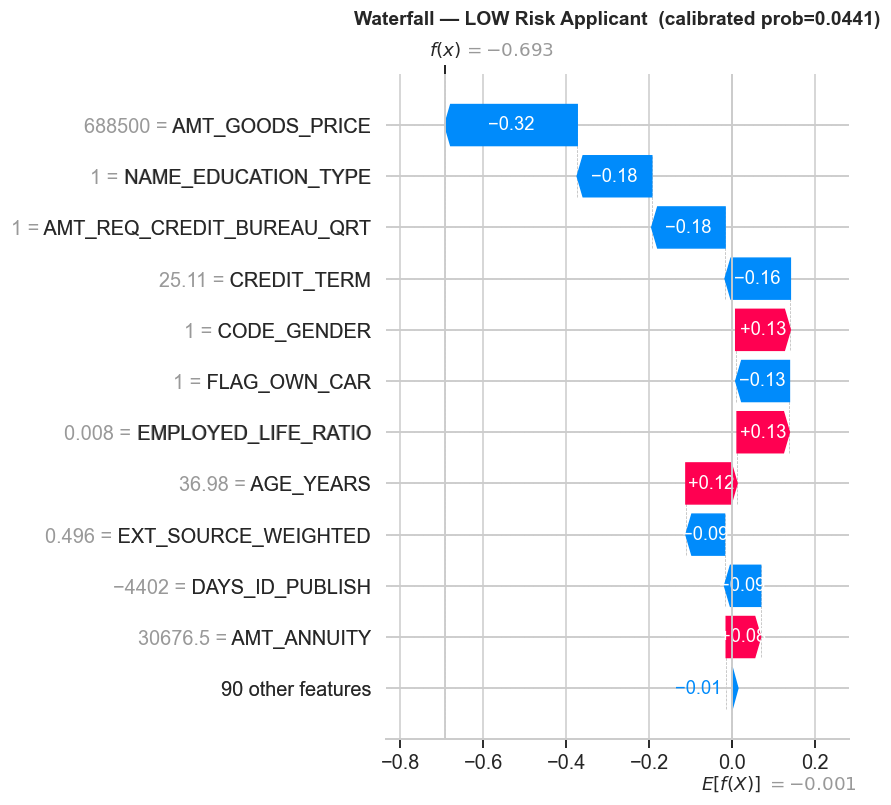

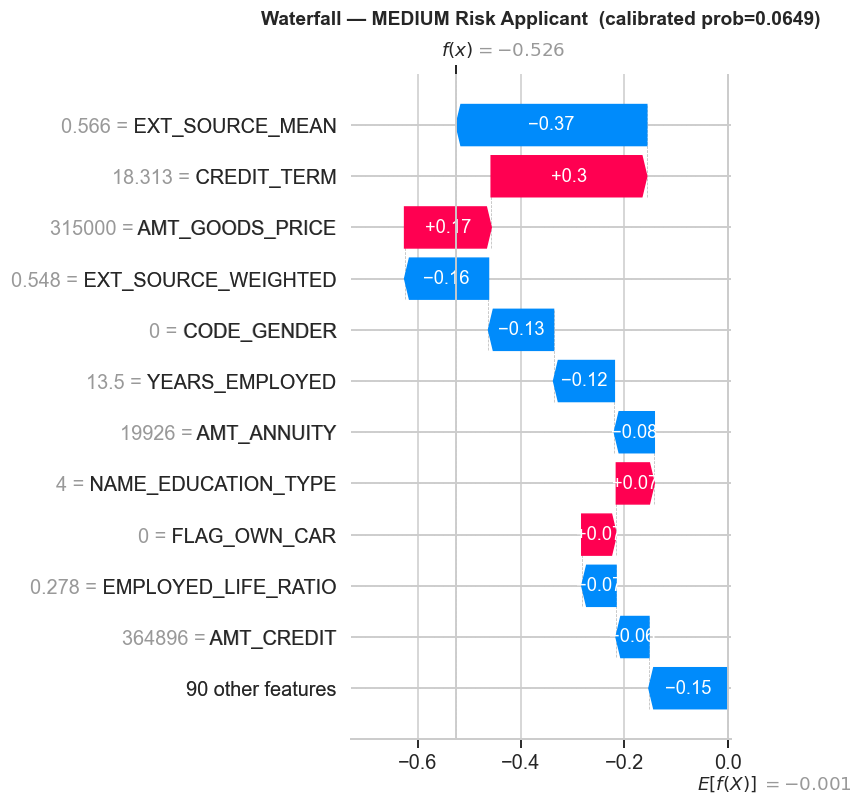

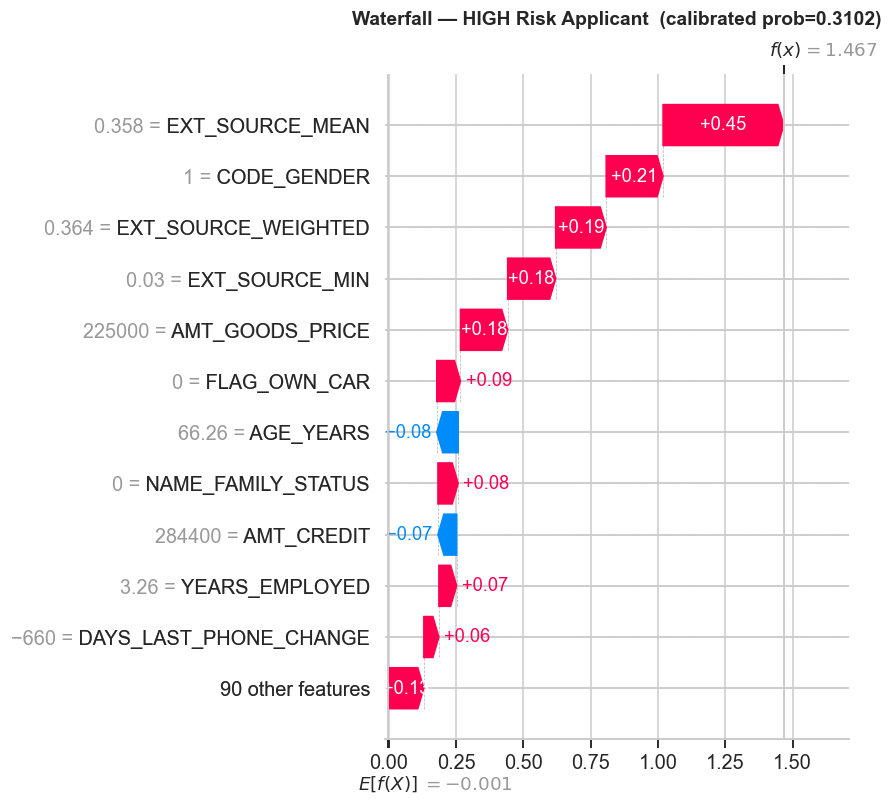

In [7]:
for i, (band, idx) in enumerate(band_examples.items()):
    prob_cal = xgb_cal.predict_proba(X_test.loc[[idx]])[:, 1][0]
    expl_obj = shap.Explanation(
        values=shap_local[i],
        base_values=float(explainer.expected_value),
        data=X_local.iloc[i].values,
        feature_names=feature_names,
    )
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(expl_obj, max_display=12, show=False)
    plt.title(
        f'Waterfall — {band} Risk Applicant  '
        f'(calibrated prob={prob_cal:.4f})',
        fontweight='bold', pad=10
    )
    plt.tight_layout()
    plt.show()


---
## 3. Adverse Action Reason Codes

When a credit application is declined, regulators require the lender to notify the applicant of the **specific reasons** for the adverse decision.  
These are called **adverse action reason codes** (AARC).

We generate them automatically from SHAP values:
1. For each declined applicant, rank features by SHAP contribution (descending)
2. Take the top 3 features — these are the primary drivers of rejection
3. Format into a human-readable sentence using a reason-code template

This approach is **model-faithful** (reasons reflect actual model behaviour), **consistent** (same feature always gets the same template), and **auditable** (SHAP values are logged alongside the decision).

In [8]:
# Features that must never appear in adverse action reason codes
# (prohibited characteristics or demographic proxies)
EXCLUDED_FROM_REASONS = {
    'CODE_GENDER', 'CODE_GENDER_missing',
    'NAME_FAMILY_STATUS', 'NAME_FAMILY_STATUS_missing',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'NAME_HOUSING_TYPE', 'NAME_HOUSING_TYPE_missing',
    'REGION_POPULATION_RELATIVE',
    'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
}

# Human-readable reason code templates
REASON_TEMPLATES = {
    'EXT_SOURCE_MEAN'           : 'Low external credit score',
    'EXT_SOURCE_MIN'            : 'Low minimum external credit score',
    'EXT_SOURCE_WEIGHTED'       : 'Low weighted external credit score',
    'EXT_SOURCE_1'              : 'Low credit bureau score (source 1)',
    'EXT_SOURCE_2'              : 'Low credit bureau score (source 2)',
    'EXT_SOURCE_3'              : 'Low credit bureau score (source 3)',
    'CREDIT_INCOME_RATIO'       : 'High debt-to-income ratio',
    'ANNUITY_INCOME_RATIO'      : 'High repayment burden relative to income',
    'CREDIT_TERM'               : 'Long implied loan term',
    'EMPLOYED_LIFE_RATIO'       : 'Short employment history relative to age',
    'INCOME_PER_PERSON'         : 'Low household income per person',
    'YEARS_EMPLOYED'            : 'Short employment history',
    'AGE_YEARS'                 : 'Applicant age',
    'AMT_CREDIT'                : 'Requested loan amount',
    'AMT_INCOME_TOTAL'          : 'Income level',
    'AMT_ANNUITY'               : 'Monthly repayment amount',
    'AMT_GOODS_PRICE'           : 'Goods price',
    'DAYS_EMPLOYED_anomaly'     : 'Irregular employment record',
    'DOCUMENT_FLAGS_SUM'        : 'Insufficient documentation provided',
    'SOCIAL_CIRCLE_DEFAULT_RATE': 'High default rate in social circle',
    'REGION_RATING_CLIENT'      : 'High-risk residential region',
    'EXT_SOURCE_1_missing'      : 'Missing credit bureau record (source 1)',
}

# Features treated as currency (format as $X,XXX)
CURRENCY_FEATURES = {'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
                     'AMT_GOODS_PRICE', 'INCOME_PER_PERSON'}

# Features treated as age in whole years
AGE_FEATURES = {'AGE_YEARS'}

# Features treated as ratios (2 decimal places)
RATIO_FEATURES = {'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
                  'EMPLOYED_LIFE_RATIO', 'SOCIAL_CIRCLE_DEFAULT_RATE',
                  'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_WEIGHTED',
                  'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'}


def format_value(feat, value):
    if feat in CURRENCY_FEATURES:
        return f'${value:,.0f}'
    if feat in AGE_FEATURES:
        return f'{int(round(value))} years'
    if feat in RATIO_FEATURES:
        return f'{value:.2f}'
    return f'{value:.4g}'


def format_reason(feat, value):
    label = REASON_TEMPLATES.get(feat, feat.replace('_', ' ').title())
    return f'{label} ({feat} = {format_value(feat, value)})'


def get_adverse_action_codes(idx, top_n=3):
    sv        = explainer.shap_values(X_test.loc[[idx]])[0]
    prob      = xgb_cal.predict_proba(X_test.loc[[idx]])[:, 1][0]
    feat_shap = pd.Series(sv, index=feature_names)
    eligible  = feat_shap[
        (feat_shap > 0) & (~feat_shap.index.isin(EXCLUDED_FROM_REASONS))
    ]
    drivers   = eligible.nlargest(top_n)
    reasons   = [
        format_reason(feat, float(X_test.loc[idx, feat]))
        for feat in drivers.index
    ]
    return prob, reasons


high_risk_idx = bands[bands == 'HIGH'].index
print(f'HIGH risk applicants in test set: {len(high_risk_idx):,}')
print(f'Excluded demographic features   : {len(EXCLUDED_FROM_REASONS)}')
print('\nShowing 10 example adverse action notices:')
print('=' * 60)
for i, idx in enumerate(high_risk_idx[:10], 1):
    prob, reasons = get_adverse_action_codes(idx)
    print(f'\nApplicant {i}  |  Default probability: {prob:.4f}')
    print('Reasons for decline:')
    for j, reason in enumerate(reasons, 1):
        print(f'  {j}. {reason}')


HIGH risk applicants in test set: 8,881
Excluded demographic features   : 15

Showing 10 example adverse action notices:

Applicant 1  |  Default probability: 0.3102
Reasons for decline:
  1. Low external credit score (EXT_SOURCE_MEAN = 0.36)
  2. Low weighted external credit score (EXT_SOURCE_WEIGHTED = 0.36)
  3. Low minimum external credit score (EXT_SOURCE_MIN = 0.03)

Applicant 2  |  Default probability: 0.3609
Reasons for decline:
  1. Low external credit score (EXT_SOURCE_MEAN = 0.27)
  2. Low weighted external credit score (EXT_SOURCE_WEIGHTED = 0.21)
  3. Long implied loan term (CREDIT_TERM = 12.54)

Applicant 3  |  Default probability: 0.2846
Reasons for decline:
  1. Low external credit score (EXT_SOURCE_MEAN = 0.36)
  2. Long implied loan term (CREDIT_TERM = 12.66)
  3. Goods price (AMT_GOODS_PRICE = $225,000)

Applicant 4  |  Default probability: 0.2463
Reasons for decline:
  1. Long implied loan term (CREDIT_TERM = 12.58)
  2. Low external credit score (EXT_SOURCE_MEAN = 

---
## 4. Calibration Analysis

A model is **well-calibrated** if its predicted probabilities match observed frequencies: when the model says 'probability of default = 20%', roughly 20% of such applicants should actually default.

**Why calibration matters in credit scoring:**
- The **portfolio simulation** (expected loss) relies on predicted probabilities being accurate
- **Pricing** — interest rate = cost of funds + expected loss — requires a calibrated PD
- **Regulatory capital** (Basel IRB approach) uses PD directly in the risk-weight formula

The **reliability diagram** plots predicted probability buckets vs actual default rate.  
A perfectly calibrated model lies on the diagonal.

The **Brier score** decomposes into:
- `Reliability` — how far predictions are from the calibration diagonal (lower = better)
- `Resolution` — how much predictions vary (higher = better, means model is discriminating)
- `Uncertainty` — baseline variance of the target (fixed by the data)

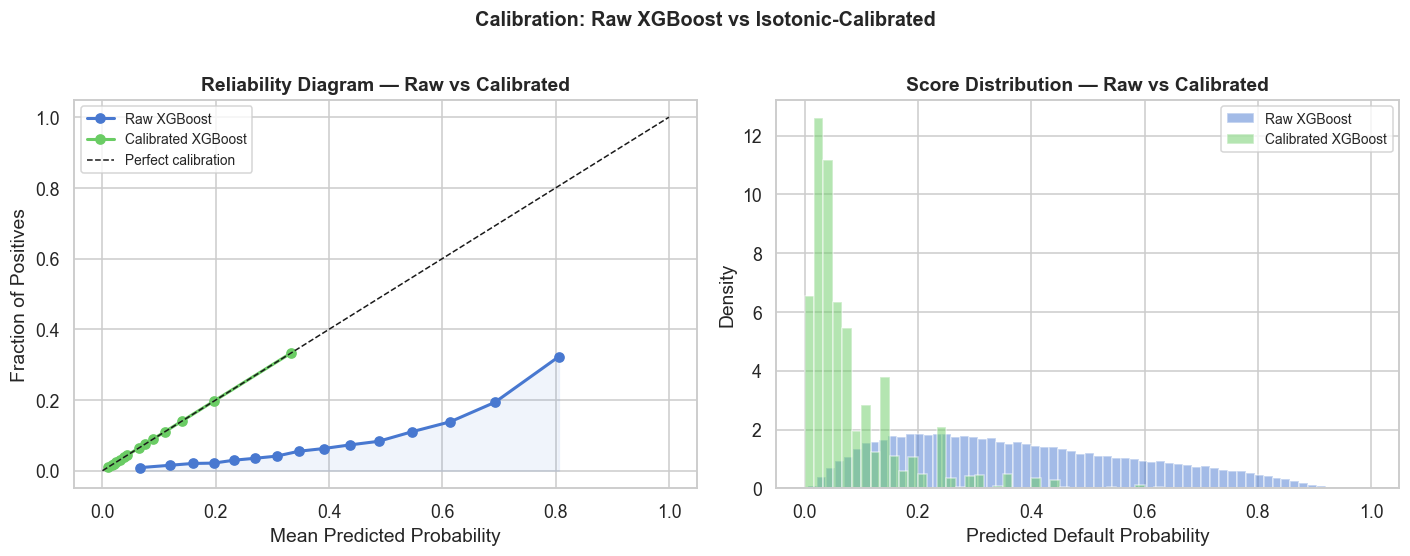

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for label, prob, color in [
    ('Raw XGBoost',        y_prob_raw, sns.color_palette('muted')[0]),
    ('Calibrated XGBoost', y_prob_cal, sns.color_palette('muted')[2]),
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=15, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', lw=2, color=color, label=label)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.fill_between(
    *calibration_curve(y_test, y_prob_raw, n_bins=15, strategy='quantile')[::-1],
    alpha=0.08, color=sns.color_palette('muted')[0]
)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Reliability Diagram — Raw vs Calibrated', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
for label, prob, color in [
    ('Raw XGBoost',        y_prob_raw, sns.color_palette('muted')[0]),
    ('Calibrated XGBoost', y_prob_cal, sns.color_palette('muted')[2]),
]:
    ax.hist(prob, bins=60, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel('Predicted Default Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution — Raw vs Calibrated', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Calibration: Raw XGBoost vs Isotonic-Calibrated', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [10]:
base_rate    = y_test.mean()
brier_base   = base_rate * (1 - base_rate)
n_bins       = 15

print('=== Brier Score Comparison ===')
for label, prob in [('Raw XGBoost', y_prob_raw), ('Calibrated XGBoost', y_prob_cal)]:
    brier = brier_score_loss(y_test, prob)
    skill = 1 - brier / brier_base
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=n_bins, strategy='quantile')
    reliability = float(np.mean((mean_pred - frac_pos) ** 2))
    resolution  = float(np.mean((frac_pos  - base_rate) ** 2))
    print(f'\n{label}')
    print(f'  Brier Score  : {brier:.4f}')
    print(f'  Skill Score  : {skill:.4f}')
    print(f'  Reliability  : {reliability:.6f}  (calibration error, lower=better)')
    print(f'  Resolution   : {resolution:.6f}  (discrimination, higher=better)')

print('\n--- Verdict ---')
cal_brier = brier_score_loss(y_test, y_prob_cal)
raw_brier = brier_score_loss(y_test, y_prob_raw)
improvement = (raw_brier - cal_brier) / raw_brier * 100
print(f'Calibration reduced Brier score by {improvement:.1f}%')
frac_cal, pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=n_bins, strategy='quantile')
rel_cal = float(np.mean((pred_cal - frac_cal) ** 2))
if rel_cal < 0.005:
    print('Calibration: GOOD — probabilities are reliable for pricing and capital calculations.')
elif rel_cal < 0.02:
    print('Calibration: MODERATE — improved, but further tuning may help.')
else:
    print('Calibration: still needs work — consider more calibration data or recalibrating on a dedicated holdout.')


=== Brier Score Comparison ===

Raw XGBoost
  Brier Score  : 0.1751
  Skill Score  : -1.3597
  Reliability  : 0.107856  (calibration error, lower=better)
  Resolution   : 0.006626  (discrimination, higher=better)

Calibrated XGBoost
  Brier Score  : 0.0669
  Skill Score  : 0.0989
  Reliability  : 0.000000  (calibration error, lower=better)
  Resolution   : 0.007380  (discrimination, higher=better)

--- Verdict ---
Calibration reduced Brier score by 61.8%
Calibration: GOOD — probabilities are reliable for pricing and capital calculations.


---
## Summary

| Section | Key output |
|---|---|
| **Global SHAP** | `EXT_SOURCE_*` scores and credit ratio features dominate globally |
| **Local SHAP** | Each applicant's score decomposes cleanly into feature contributions |
| **Adverse action codes** | Top-3 SHAP drivers formatted as regulator-ready reason statements |
| **Calibration** | Reliability diagram shows where the model over/under-estimates risk |
